## Import Libraries

In [2]:
# Basic Machine Learning libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_absolute_error
from IPython.display import display
from itertools import product

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Task 1  
Load the data set **wine-full.csv**. Do you think the score (quality) is balanced? Justify, including the corresponding plot.


### Answer: Do you think the score (quality) is balanced?

The quality value is not balanced. By looking at the barplot we can make an observation that 3,4,8,9 values of quality are very low regarding other categories:

    Value 3 appears 30 times
    Value 4 appears 216 times
    Value 5 appears 2138 times
    Value 6 appears 2836 times
    Value 7 appears 1079 times
    Value 8 appears 193 times
    Value 9 appears 5 times



,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Value `3` appears 30 times
Value `4` appears 216 times
Value `5` appears 2138 times
Value `6` appears 2836 times
Value `7` appears 1079 times
Value `8` appears 193 times
Value `9` appears 5 times


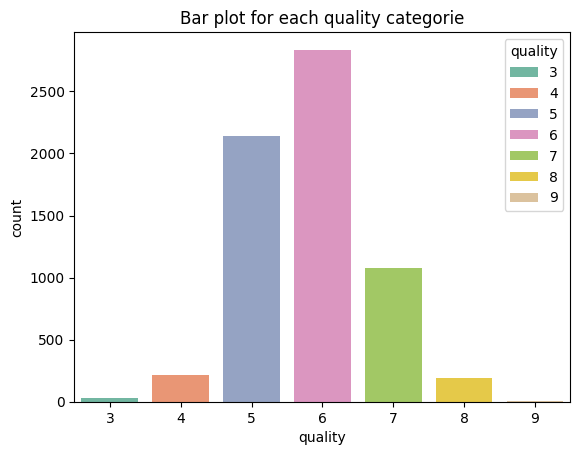

In [13]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/wine-full.csv')
display(df)

# Print count of each quality unique value
value, count = np.unique(df['quality'], return_counts=True)
for i in range(len(count)):
    print(f"Value `{value[i]}` appears {count[i]} times")

# Show barplot (countplot in seaborn)
sns.countplot(data=df, x='quality', hue='quality',palette = "Set2")
plt.title("Bar plot for each quality categorie")
plt.show()

### Check if there are Nan values
Since Nan values are not too many we can drop them

In [14]:
display(df.isna().sum())
df.dropna(inplace=True)
display(df.isna().sum())

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


## Task 2  
The question is often raised: **Is red or white wine qualitatively better?** Apply appropriate methodology and plots to justify your answer.


### Answer: Is red or white wine qualitatively better?

Considering that a wine has good quality when quality value is greater than 5 we set 5 as the baseline. If value is under 5 wine is not good and if it is greater than 5 is good enough. Since 5 is the baseline if wine has quality of 5 then it is not easy to categorize if it is good or not
By making this condieration white wine has better quality since 66.52% of white wines are above the baseline instead of the red wine in which only 53.47% of red wines are above the baseline.

---
**Code results:**

    There are 855 red wines with good quality.
    On average the 53.47% of red wines are good

    There are 3258 white wines with good quality.
    On average the 66.52% of white wines are good


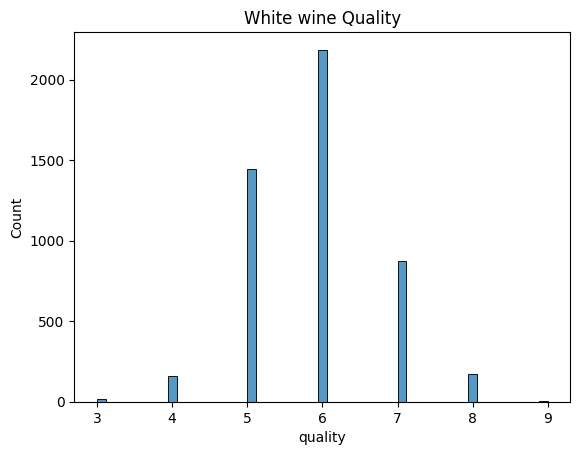

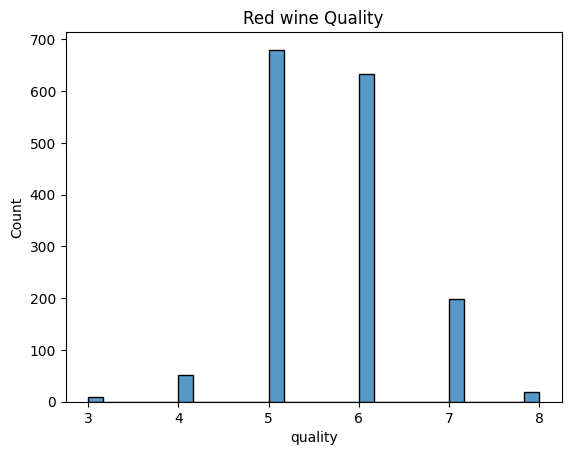

There are 851 red wines with good quality.
On average the 53.42% of red wines are good

There are 3240 white wines with good quality.
On average the 66.53% of white wines are good


In [15]:
# Create seperate dfs for red and white wine
red_wine = df[df['type']=='red']
white_wine = df[df['type']=='white']

# Histogram for white wine quality
sns.histplot(white_wine, x='quality')
plt.title('White wine Quality')
plt.show()


# Histogram for red wine quality
sns.histplot(red_wine, x='quality')
plt.title('Red wine Quality')
plt.show()

# Calculate the count of good quality red and white wines
red_count_of_good_quality = sum(red_wine['quality']>5)
white_count_of_good_quality = sum(white_wine['quality']>5)

# Calculate the average of good quality red and white wine
red_average = round(red_count_of_good_quality/len(red_wine)*100, 2)
white_average = round(white_count_of_good_quality/len(white_wine)*100, 2)

print(f"There are {red_count_of_good_quality} red wines with good quality.\nOn average the {red_average}% of red wines are good\n")
print(f"There are {white_count_of_good_quality} white wines with good quality.\nOn average the {white_average}% of white wines are good")

## Task 3  
Is **sweet wine of higher quality than dry wine**? Justify your answer, taking into account the amount of residual sugars.


### Answer: sweet wine of higher quality than dry wine?

- Same as before, we set the baseline to 5 regarding the quality value.
- If residual sugar is:
    - equal or less to 4 then wine is dry
    - equal or above 8 then wine is sweet
    - between 4 and 8 is semi-dry
By making this condieration dry wine has better quality since 63.55% of white wines are above the baseline instead of the sweet wines in which only 60.3% of them are above the baseline.

To answer the question sweet wine has not better quality than dry wine regarding this dataset.

---
**Code results:**

    There are 2268 dry wines with good quality.
    On average the 63.55% of dry wines are good

    There are 1010 sweet wines with good quality.
    On average the 60.3% of sweet wines are good


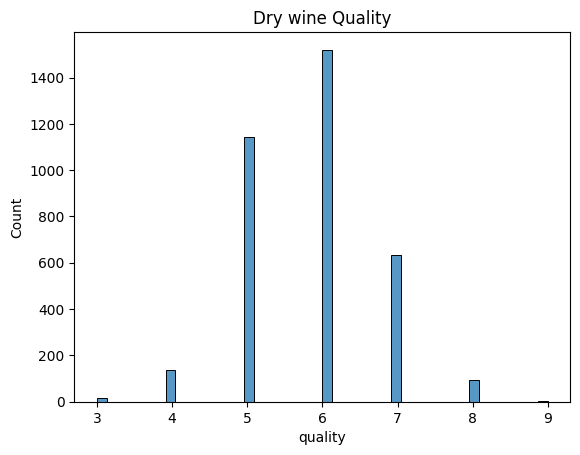

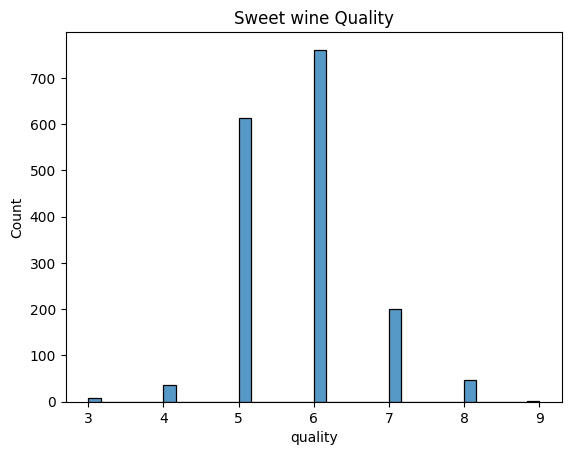

There are 2253 dry wines with good quality.
On average the 63.46% of dry wines are good

There are 1008 sweet wines with good quality.
On average the 60.5% of sweet wines are good


In [16]:
# Create seperate dfs for dry and sweet wines
dry_wine = df[df['residual sugar']<=4]
sweet_wine = df[df['residual sugar']>=8]

# Histogram for dry and sweet quality
sns.histplot(dry_wine, x='quality')
plt.title('Dry wine Quality')
plt.show()


# Histogram for sweet wine quality
sns.histplot(sweet_wine, x='quality')
plt.title('Sweet wine Quality')
plt.show()

# Calculate the count of good quality dry and sweet wines
dry_count_of_good_quality = sum(dry_wine['quality']>5)
sweet_count_of_good_quality = sum(sweet_wine['quality']>5)

# Calculate the average of good quality dry and sweet wine
dry_average = round(dry_count_of_good_quality/len(dry_wine)*100, 2)
sweet_average = round(sweet_count_of_good_quality/len(sweet_wine)*100, 2)

print(f"There are {dry_count_of_good_quality} dry wines with good quality.\nOn average the {dry_average}% of dry wines are good\n")
print(f"There are {sweet_count_of_good_quality} sweet wines with good quality.\nOn average the {sweet_average}% of sweet wines are good")

## Task 4  
Create numpy arrays **x, y** where the inputs are all variables except *quality*, while **y** is the *quality* variable. Split the data set into **train-test** with percentages of **90-10** respectively. Use `random_state=0`.


### Extra step to make model working
It is essential to convert red-white to numerical values instead of string. This will ensure model will not throw an error
- white = 0
- red = 1

In [17]:
# Get the type and change the value
df.loc[df['type'] == 'white', 'type'] = 0
df.loc[df['type'] == 'red', 'type'] = 1
df


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,0,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,0,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,0,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,0,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,1,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,1,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6494,1,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,1,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [18]:
# initialize train-test-split variables
test_size = 0.1
random_state = 0

# Create numpy arrays x features and y labels
x = df.drop('quality', axis=1).to_numpy()
y = df['quality'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)

# Print results to ensure everything worked well
print("x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)

print("-"*70)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)

x_train shape:  (5816, 12)
y_train shape:  (5816,)
----------------------------------------------------------------------
x_test shape:  (647, 12)
y_test shape:  (647,)


## Task 5  
Train a **DecisionTreeRegressor (random_state=0)** on the training set and calculate the error with the **MAE** metric on the test set.


In [19]:
# Initialize Decision Tree Regressor
dtr = tree.DecisionTreeRegressor(random_state=random_state)
# Train Regressor
dtr.fit(X=x_train, y=y_train)

DecisionTreeRegressor(random_state=0)

### Calculate mean absolute error

In [20]:
# Get the predictions
y_pred = dtr.predict(X=x_test)

# Calculate mean absolute error
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)

# Print results
print(f"Decision Tree Regressiong Mean Absolute Error --> {mae:.4f}")

Decision Tree Regressiong Mean Absolute Error --> 0.4405


## Task 6  
We want to calculate whether the model in question 4 is reliable. Repeat steps 3-4, using **10 different seeds (0–9)**. Then, calculate the **mean and standard deviation** for the MAE metric. How can we use these values to be more confident about the expected error of the model?


### Answer: How can we use these values to be more confident about the expected error of the model?

**Code results:**

| **Metric**           | **Value** |
|----------------------|-----------|
|**Mean MAE**          | 0.4622    |
|**Standard Deviation**| 0.0252    |

**After trying 10 different seeds (0-9):**

Standard Deviation: Sdt value is very low meaning that the model is very stable and it doesn't have large fluctuations

Mean of MAE: mae value does not change significantly. In every seed mae value is in range --> [0.4-0.5]

Final Conclusion: model is consistent and reliable with error close to 0.46 ± 0.03


In [21]:
# initialize test_size
test_size = 0.1
mae_list = []

# For loop to test every seed (0-9)
for random_state in range(0,10):

    # Split the dataset to Train and Test sets
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)

    # Initialize Decision Tree Regressor
    dtr = tree.DecisionTreeRegressor(random_state=random_state)

    # Train Regressor
    dtr.fit(X=x_train, y=y_train)

    # Get the predictions
    y_pred = dtr.predict(X=x_test)

    # Calculate mean absolute error
    mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
    mae_list.append(mae)

    # Print results
    print(f"Decision Tree Regressiong Mean Absolute Error --> {mae:.4f}")

print('\n====================\n')
# Calculate the mean of MAE
mean_mae = np.mean(mae_list)

# Calculate the mean of standard deviation
std_mae = np.std(mae_list)

print(f"Mean of Mae --> {mean_mae:.4f}")
print(f"Mean of standard deviation --> {std_mae:.4f}")

Decision Tree Regressiong Mean Absolute Error --> 0.4405
Decision Tree Regressiong Mean Absolute Error --> 0.5131
Decision Tree Regressiong Mean Absolute Error --> 0.4621
Decision Tree Regressiong Mean Absolute Error --> 0.4389
Decision Tree Regressiong Mean Absolute Error --> 0.4498
Decision Tree Regressiong Mean Absolute Error --> 0.4621
Decision Tree Regressiong Mean Absolute Error --> 0.4621
Decision Tree Regressiong Mean Absolute Error --> 0.4389
Decision Tree Regressiong Mean Absolute Error --> 0.4513
Decision Tree Regressiong Mean Absolute Error --> 0.5147


Mean of Mae --> 0.4634
Mean of standard deviation --> 0.0268


## Task 7  
Split the train set into **train-validation** with percentages of **80-20%** respectively, using `random_state=0`.  
You should have **3 data sets (train-validation-test)** with percentages of **70-20-10** of the total dataset.  
We want to do some **fine-tuning (finding hyperparameters)** to improve the accuracy of the tree (question 3).  
Try **15 different combinations** with parameters of your choice, always keeping `random_state=0`, and calculate the **MAE** in the training and validation sets for each combination.


### Split train set into train-validation set

In [22]:
# Again train-test split to get seed = 0 (because in the previous step x_train change seeds)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)

dtr = tree.DecisionTreeRegressor(random_state=random_state)
dtr.fit(x_train,y_train)

# Use 2/9 because x_train is the 90% of the dataset and we want the validation set to be the 20% of the dataset
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=2/9, random_state=0)

# Print results to ensure everything worked well
print("x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)

print("-"*70)
print("x_val shape: ",x_val.shape)
print("y_val shape: ",y_val.shape)

# Ensure split was correct (70%-20%-10%)
print(f"Train: {len(x_train)/len(x):.2%}")
print(f"Validation: {len(x_val)/len(x):.2%}")
print(f"Test: {len(x_test)/len(x):.2%}")

x_train shape:  (4523, 12)
y_train shape:  (4523,)
----------------------------------------------------------------------
x_val shape:  (1293, 12)
y_val shape:  (1293,)
Train: 69.98%
Validation: 20.01%
Test: 10.01%


### Parameters Decision

Max depth and criteria are important parameters for models such as Deicion Tree Regressor. This is the reason why I decide to try 3 different criteria ('squared_error','friedman_mse', 'absolute_error') and 5 different max_depths to create 15 different combinations (3, 5, 7, 10, 15).

**Explain criteria:**
- squared_error: Uses Mean Squared Error as a measure of impoutiry. For this example such a criterio might cause good results since we try to find the best MAE value
- friedman_mse: A variant of MASE optimized for gradient boosting
- absolute_error: For the mean absolute error, which minimizes the L1 loss


In [23]:
# Initialize Decision tree parameters
criteria = ['squared_error','friedman_mse', 'absolute_error']
max_depths = [3, 5, 7, 10, 15]

# Create a dict to save the accuracy results for test and train set
result_list = []
count = 1

for cri, max_d in product(criteria, max_depths):

  # Create model --> setting parameters
  dtr = tree.DecisionTreeRegressor(
      criterion = cri,
      max_depth = max_d,
      random_state=0)

  # Train model
  dtr.fit(x_train, y_train)

  # Get predictions for train test
  y_predict_train = dtr.predict(x_train)
  # Get accuracy score
  mae_train = mean_absolute_error(y_train, y_predict_train)

  # Get predictions for test set
  y_predict_val = dtr.predict(x_val)
  # Get accuracy score
  mae_val = mean_absolute_error(y_val, y_predict_val)

  # Save info into a list
  result_list.append({
      'criterion': cri,
      'max_depth': max_d,
      'mean_absolute_error train': mae_train,
      'mean_absolute_error validation': mae_val,
      })
  print(f"Loop {count} finished successfuly.....✅")
  count+=1

# Convert list to dataframe to make results more readable
rdf_results_df = pd.DataFrame(result_list)
rdf_results_df

Loop 1 finished successfuly.....✅
Loop 2 finished successfuly.....✅
Loop 3 finished successfuly.....✅
Loop 4 finished successfuly.....✅
Loop 5 finished successfuly.....✅
Loop 6 finished successfuly.....✅
Loop 7 finished successfuly.....✅
Loop 8 finished successfuly.....✅
Loop 9 finished successfuly.....✅
Loop 10 finished successfuly.....✅
Loop 11 finished successfuly.....✅
Loop 12 finished successfuly.....✅
Loop 13 finished successfuly.....✅
Loop 14 finished successfuly.....✅
Loop 15 finished successfuly.....✅


,criterion,max_depth,mean_absolute_error train,mean_absolute_error validation
0,squared_error,3,0.584469,0.605296
1,squared_error,5,0.538965,0.572077
2,squared_error,7,0.482371,0.557632
3,squared_error,10,0.348680,0.558509
4,squared_error,15,0.103321,0.520386
5,friedman_mse,3,0.584469,0.605296
6,friedman_mse,5,0.538965,0.572077
7,friedman_mse,7,0.482371,0.557632
8,friedman_mse,10,0.348680,0.558509
9,friedman_mse,15,0.103321,0.520128


## Task 8  
Which of the two datasets (**training or validation set**) is more reliable for **hyperparameter selection**? Justify.


### Answer
Validation set is more reliable for hyperparameter selection since the model not use it during training and so is providess and unbiased estimate on how the model should perform in unseen data. Training set is used to fit the model and validation set is used to evaluate different hyperparameter and choose which of these helpo the model to generalizes the best before the final testing in the test set.

## Task 9  
We will try the **cross-validation method** for parameter selection.  
Use the **train-test dataset** from question 4.  
This time, however, fine-tune with the help of **cross-validation** on the train set.  
For convenience, you can use the **GridSearchCV** function of sklearn:  
https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html  

More specifically, instead of having a fixed validation set, sklearn will split the train set *K* times into *K* different train-validation sets and calculate the **average error**.  
Use the **MAE** metric as scoring, `random_state=0`, and set `cv=10` to create *K=10 folds*.  
You can parallelize the process by setting `n_jobs=-1` to use all processor cores.


### Code explanation

- Split the dataset into train-test set
- Initialize previous parameters and call GridSearchCV
    - Set estimator to the model
    - Create a param grid passing the paramaeters from the previous stage
    - Set scoring to neg_mean_absolute_error since mean_absolute_error doesn't exist as a value for GridSearchCV

In [24]:
# Same train-test split from question 4
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)

# Initialize parameters
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [3, 5, 7, 10, 15]
}

dtr = tree.DecisionTreeRegressor(random_state=0)

grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, scoring='neg_mean_absolute_error', cv=10, n_jobs=-1)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [3, 5, 7, 10, 15]},
             scoring='neg_mean_absolute_error')

## Task 10  
Use the **best model of question 9** and calculate the **MAE** metric on the test set.  
Which of the methodologies followed (**6 / 7 / 9**) is more reliable? Justify.


### Answer: Which of the methodologies followed (**6 / 7 / 9**) is more reliable?

Among these 3 methodologies the cross validation approach is more reliable to select the model paramaters and have better evaluation.
- Validation approach used training set efficient because instead of keeping the validation fixed it uses 10 kFolds to get all posible subsets.
- Reduce the dependence of random state or data split
- Allow fine tuning regariding the mean error of all folds

Single split (Question 7) and different random seeds (Question 6) are reducing the variance of the model because of splitting. These methods have more robust estimations of the expected model error.

In [25]:
# Initialize model and train the model in training set
dtr = tree.DecisionTreeRegressor(**grid_search.best_params_, random_state=0) #unzip dictionary and get parameter values
dtr.fit(x_train, y_train)

# Get predictions
y_pred = dtr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Square Error using parameters from grid search: {mae:.4f}')

Mean Square Error using parameters from grid search: 0.4489


## Task 11  
Repeat question 9, always using a fixed `max_depth=5`.  
Display the **best tree** (using `plot_tree`).  
In addition, report the **rules created** (e.g., wine has a high score if it contains a lot of sugar, is red, etc.).  
Finally, display a **bar chart** with the **importance of each feature**, sorting them based on their importance.


### Initialize GridSearch

Add min_samples_slit because in previous stages we had 15 different combinations but with max_depth=5 (fixed) it was important to find different parameter to create again the 15 different combinations

In [26]:
# Same train-test split from question 4
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)

# Initialize parameters
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'min_samples_split': [2, 5, 10, 15, 20]
}

dtr = tree.DecisionTreeRegressor(max_depth=5, random_state=0)

grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, scoring='neg_mean_absolute_error', cv=10, n_jobs=-1)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=10,
             estimator=DecisionTreeRegressor(max_depth=5, random_state=0),
             n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'min_samples_split': [2, 5, 10, 15, 20]},
             scoring='neg_mean_absolute_error')

In [27]:
# Initialize model and train the model in training set
dtr = tree.DecisionTreeRegressor(**grid_search.best_params_, max_depth=5, random_state=0) #unzip dictionary and get parameter values
dtr.fit(x_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=5,
                      min_samples_split=10, random_state=0)

### Answer: Report the rules created

Since Tree is big enough having too many conditions I tried to summarize them and provide observations for each emportant feature mentioned in the tree without describing each tree branch rule.

*Features are mention from the most to the least infuential*

**Alcohol:** Wines with high alcohol levels have high quality score (6-7)

**Voltatile acidity:** Wines with low volatile acidity is more likely to have higher quality scores

**Suplhates:** Also in this feature high value is associated with better quality

**Residual sugar:** Moderated levels of sugar (4-7 g/L) leads to slightly better wine quality

**Total sulfur dioxide** and **chlorides** appears in deeper nodes meaning that they have minor impact meaning that quality of wine is not changing significantly from them.

**General view:** Quality of wine is higher when wine contains more alcohol, less volatile acidity and has high sulphate value.

For this summarization helps the tree.export_text which provide more readable information than tree.plot (because of the depth of the tree)


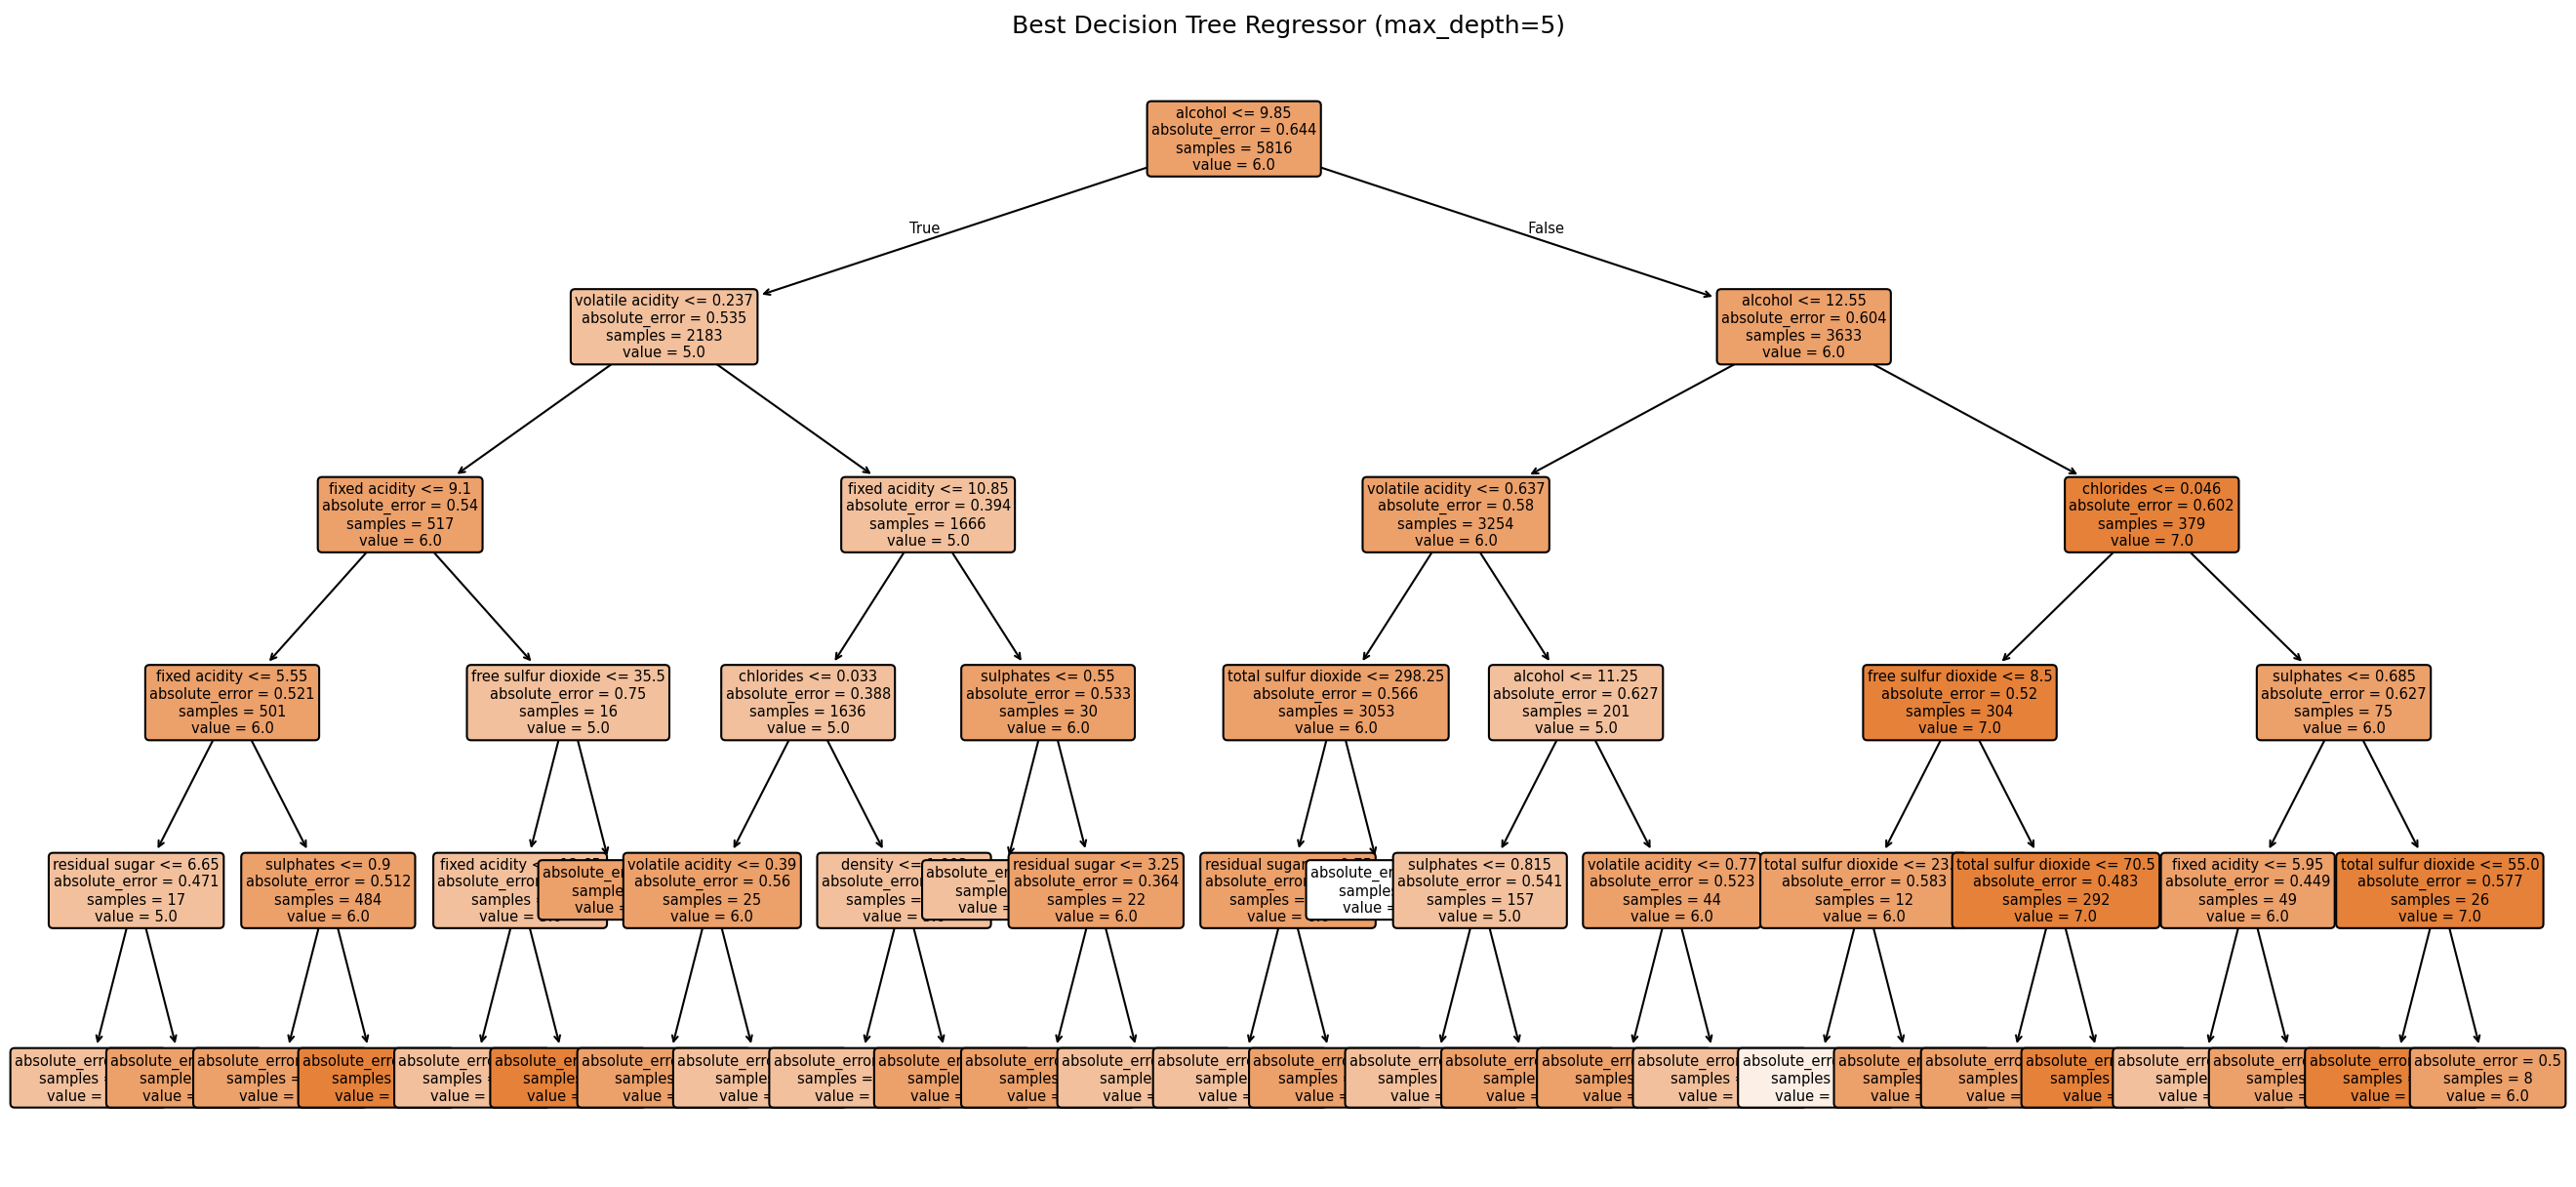

In [28]:
plt.figure(figsize=(22, 10), dpi=150)
tree.plot_tree(
    dtr,
    feature_names=df.drop('quality', axis=1).columns,
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Best Decision Tree Regressor (max_depth=5)")
plt.show()


In [29]:
feature_names = list(df.drop('quality', axis=1).columns)
tree_rules = tree.export_text(dtr, feature_names=feature_names)
print(tree_rules)

|--- alcohol <= 9.85
|   |--- volatile acidity <= 0.24
|   |   |--- fixed acidity <= 9.10
|   |   |   |--- fixed acidity <= 5.55
|   |   |   |   |--- residual sugar <= 6.65
|   |   |   |   |   |--- value: [5.00]
|   |   |   |   |--- residual sugar >  6.65
|   |   |   |   |   |--- value: [6.00]
|   |   |   |--- fixed acidity >  5.55
|   |   |   |   |--- sulphates <= 0.90
|   |   |   |   |   |--- value: [6.00]
|   |   |   |   |--- sulphates >  0.90
|   |   |   |   |   |--- value: [7.00]
|   |   |--- fixed acidity >  9.10
|   |   |   |--- free sulfur dioxide <= 35.50
|   |   |   |   |--- fixed acidity <= 12.65
|   |   |   |   |   |--- value: [5.00]
|   |   |   |   |--- fixed acidity >  12.65
|   |   |   |   |   |--- value: [7.00]
|   |   |   |--- free sulfur dioxide >  35.50
|   |   |   |   |--- value: [6.00]
|   |--- volatile acidity >  0.24
|   |   |--- fixed acidity <= 10.85
|   |   |   |--- chlorides <= 0.03
|   |   |   |   |--- volatile acidity <= 0.39
|   |   |   |   |   |--- value:

In [32]:
feature_names = list(df.drop('quality', axis = 1).columns)
feature_names

['type',
 'fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

### Explain the barchart

Bar chart is following previous observations. Alcohol is the most important feature with very high value followed by volatile acidity with also high value. Chlorides - sulphates - fixed acidity - total sulfur dioxide have low values but also places an important role. Features like pH - desnity - residual sugar - citric acid - type doesn't have an important role since they have the lowest importance. This can explain why residual sugar from previous question shows that quality of wine decreases and in the final predictions increases. This happens because with only this feature we cannot make an observation about quality results.

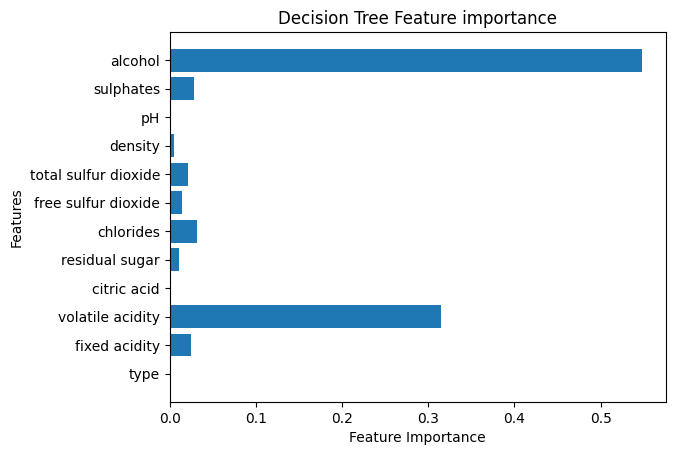

In [33]:

importance_weights = dtr.feature_importances_
plt.barh(feature_names, importance_weights)
plt.title('Decision Tree Feature importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()